In [1]:
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wav
import scipy.linalg as linalg
import matplotlib.pyplot as plt
import os

## Functions

In [2]:
def frame_signal(y, sr, frame_len_ms=25, hop_len_ms=10):
    frame_length = int(sr * (frame_len_ms / 1000.0))
    hop_length = int(sr * (hop_len_ms / 1000.0))
    num_frames = 1 + int((len(y) - frame_length) / hop_length)
    windowed_frames = np.zeros((num_frames, frame_length))
    window = np.hamming(frame_length)
    
    for i in range(num_frames):
        start = i * hop_length
        windowed_frames[i, :] = y[start:start + frame_length] * window
        
    return windowed_frames, frame_length, hop_length

def compute_lpc_and_residual(windowed_frames, N):
    num_frames, frame_length = windowed_frames.shape
    lpc_coeffs = np.zeros((num_frames, N + 1))
    residual_energy = np.zeros(num_frames)
    residuals = np.zeros_like(windowed_frames)
    
    for i in range(num_frames):
        frame = windowed_frames[i, :]
        r = np.correlate(frame, frame, mode='full')
        r = r[len(frame)-1 : len(frame)-1 + N + 1]
        R_matrix = linalg.toeplitz(r[:-1])
        r_vector = r[1:]
        R_matrix.flat[::N+1] += 1e-6 
        a_k = linalg.solve(R_matrix, r_vector)
        a = np.concatenate(([1.0], -a_k))
        lpc_coeffs[i, :] = a
        res = signal.lfilter(a, [1.0], frame)
        residuals[i, :] = res
        residual_energy[i] = np.sum(res ** 2)
        
    return lpc_coeffs, residuals, residual_energy

def reconstruct_ar_with_original_phase(windowed_frames, lpc_coeffs, N_fft=512):
    num_frames, frame_length = windowed_frames.shape
    recon_frames = np.zeros_like(windowed_frames)
    for i in range(num_frames):
        frame = windowed_frames[i, :]
        frame_fft = np.fft.rfft(frame, n=N_fft)
        original_phase = np.angle(frame_fft)
        w, h = signal.freqz([1.0], lpc_coeffs[i, :], worN=N_fft//2 + 1, include_nyquist=True)
        ar_magnitude = np.abs(h)
        gain = np.sqrt(np.sum(frame**2) / (np.sum(np.fft.irfft(ar_magnitude)**2) + 1e-10))
        ar_magnitude *= gain
        recon_fft = ar_magnitude * np.exp(1j * original_phase)
        recon_frames[i, :] = np.fft.irfft(recon_fft, n=N_fft)[:frame_length]
    return recon_frames

def synthesize_artificial(windowed_frames, lpc_coeffs, mode="white", is_voiced=None, pitch=None):
    num_frames, frame_length = windowed_frames.shape
    synth_frames = np.zeros_like(windowed_frames)
    for i in range(num_frames):
        frame_energy = np.sum(windowed_frames[i, :]**2)
        if mode == "white":
            exc = np.random.randn(frame_length)
        else: # mixed
            if is_voiced[i]:
                exc = np.zeros(frame_length)
                exc[::pitch[i]] = 1.0
            else:
                exc = np.random.randn(frame_length) * 0.1
                
        raw_synth = signal.lfilter([1.0], lpc_coeffs[i, :], exc)
        synth_energy = np.sum(raw_synth**2) + 1e-10
        # Energy matching to prevent amplitude explosion
        synth_frames[i, :] = raw_synth * np.sqrt(frame_energy / synth_energy)
    return synth_frames

def overlap_add(frames, hop_length):
    num_frames, frame_length = frames.shape
    total_length = (num_frames - 1) * hop_length + frame_length
    out_signal = np.zeros(total_length)
    for i in range(num_frames):
        start = i * hop_length
        out_signal[start:start + frame_length] += frames[i, :]
    return out_signal

def estimate_voicing_and_pitch(frames, sr):
    num_frames, frame_len = frames.shape
    is_voiced = np.zeros(num_frames, dtype=bool)
    pitch_periods = np.zeros(num_frames, dtype=int)
    energies = np.sum(frames**2, axis=1)
    energy_threshold = np.mean(energies) * 0.1 
    for i in range(num_frames):
        if energies[i] > energy_threshold:
            r = np.correlate(frames[i], frames[i], mode='full')
            r = r[frame_len-1:] 
            min_lag, max_lag = int(sr * 0.002), int(sr * 0.020)
            if max_lag < len(r):
                peak_lag = np.argmax(r[min_lag:max_lag]) + min_lag
                if r[peak_lag] > 0.3 * r[0]: 
                    is_voiced[i] = True
                    pitch_periods[i] = peak_lag
    return is_voiced, pitch_periods

def calculate_snr(original, reconstructed):
    min_len = min(len(original), len(reconstructed))
    orig_sliced = original[:min_len]
    recon_sliced = reconstructed[:min_len]
    signal_energy = np.sum(orig_sliced**2)
    noise_energy = np.sum((orig_sliced - recon_sliced)**2)
    return 10 * np.log10(signal_energy / (noise_energy + 1e-10))

def plot_waveforms_N10(filename, y, sig_phase, sig_noise, sig_mix, sr, out_dir):
    min_len = min(len(y), len(sig_phase), len(sig_noise), len(sig_mix))
    t_axis = np.arange(min_len) / sr
    fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    axs[0].plot(t_axis, y[:min_len], color='black')
    axs[0].set_title(f'Original Waveform: {filename}')
    axs[1].plot(t_axis, sig_phase[:min_len], color='blue')
    axs[1].set_title('Reconstruction: AR + Original Phase (N=10)')
    axs[2].plot(t_axis, sig_noise[:min_len], color='red')
    axs[2].set_title('Reconstruction: AR + White Noise (N=10)')
    axs[3].plot(t_axis, sig_mix[:min_len], color='green')
    axs[3].set_title('Reconstruction: AR + Mixed Excitation (N=10)')
    axs[3].set_xlabel('Time (seconds)')
    for ax in axs:
        ax.grid(True)
        ax.set_ylabel('Amplitude')
        
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'Waveforms_N10_{filename.replace(".wav", "")}.png'))
    plt.show()
    plt.close(fig)

def plot_snr_analysis(filename, N_values, snr_phase, snr_noise, snr_mix, out_dir):
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, snr_phase, marker='o', color='blue', label='AR + Original Phase')
    plt.plot(N_values, snr_noise, marker='x', color='red', label='AR + White Noise')
    plt.plot(N_values, snr_mix, marker='s', color='green', label='AR + Mixed Excitation')
    
    plt.title(f'SNR vs. Linear Prediction Order (N) for {filename}')
    plt.xlabel('Linear Prediction Order (N)')
    plt.ylabel('Signal-to-Noise Ratio (dB)')
    plt.xticks(N_values)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'SNR_vs_N_{filename.replace(".wav", "")}.png'))
    plt.show()
    plt.close()

## Q1 Linear Prediction

In [3]:
data_dir = 'data'
files = os.listdir(data_dir)
files

['Train_0_Example_1.wav',
 'Train_0_Example_2.wav',
 'Train_1_Example_1.wav',
 'Train_1_Example_2.wav']

#### Q1.a)

In [4]:
N_part_a = 10

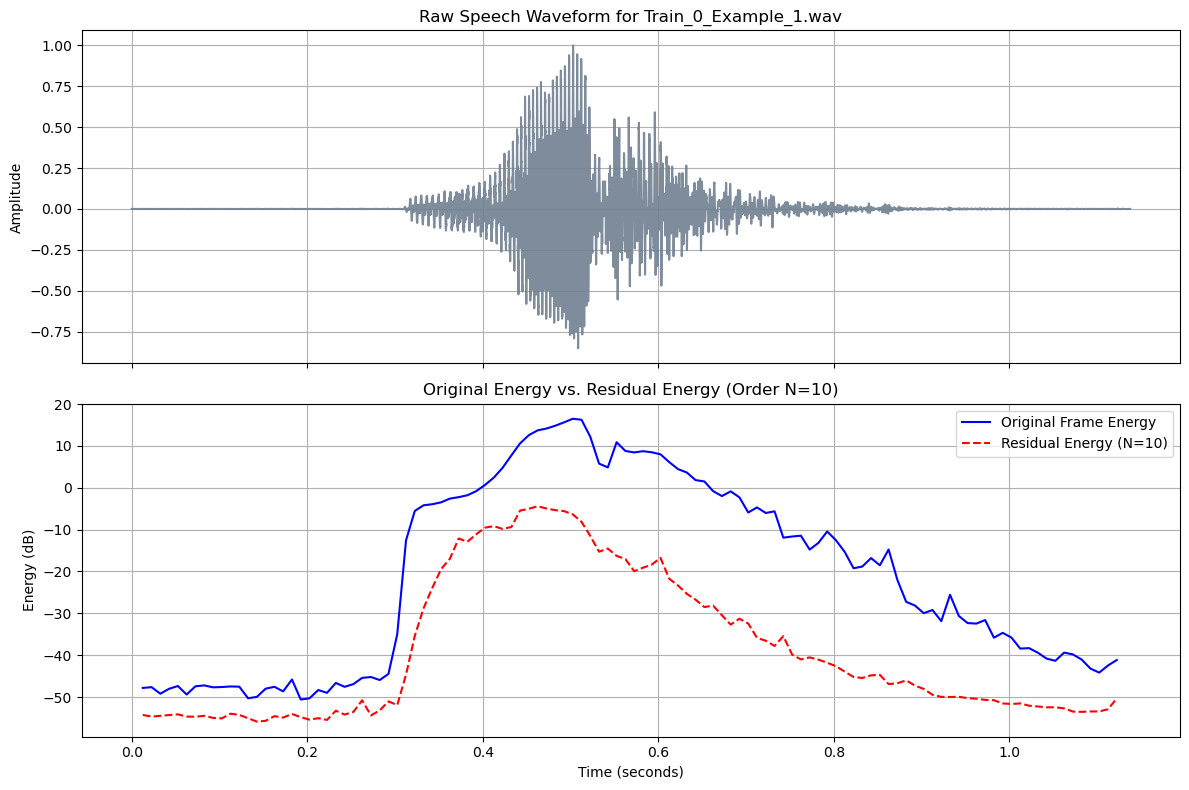

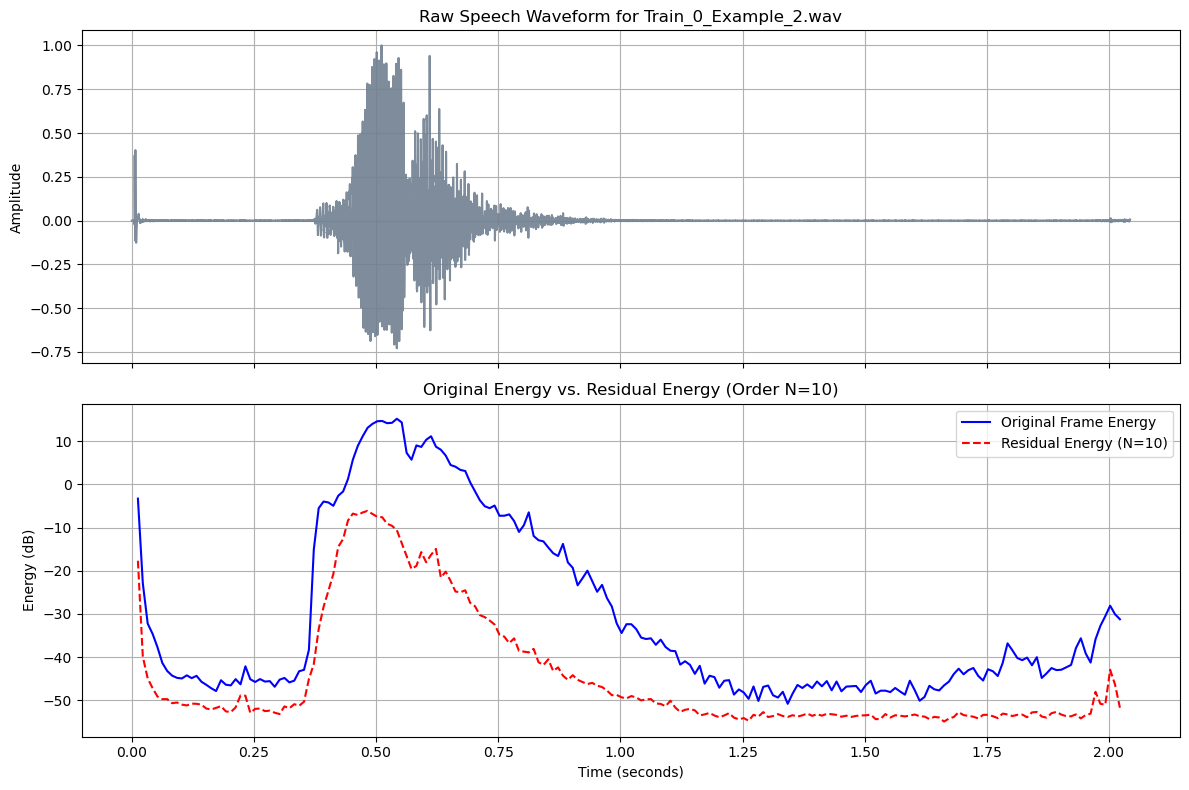

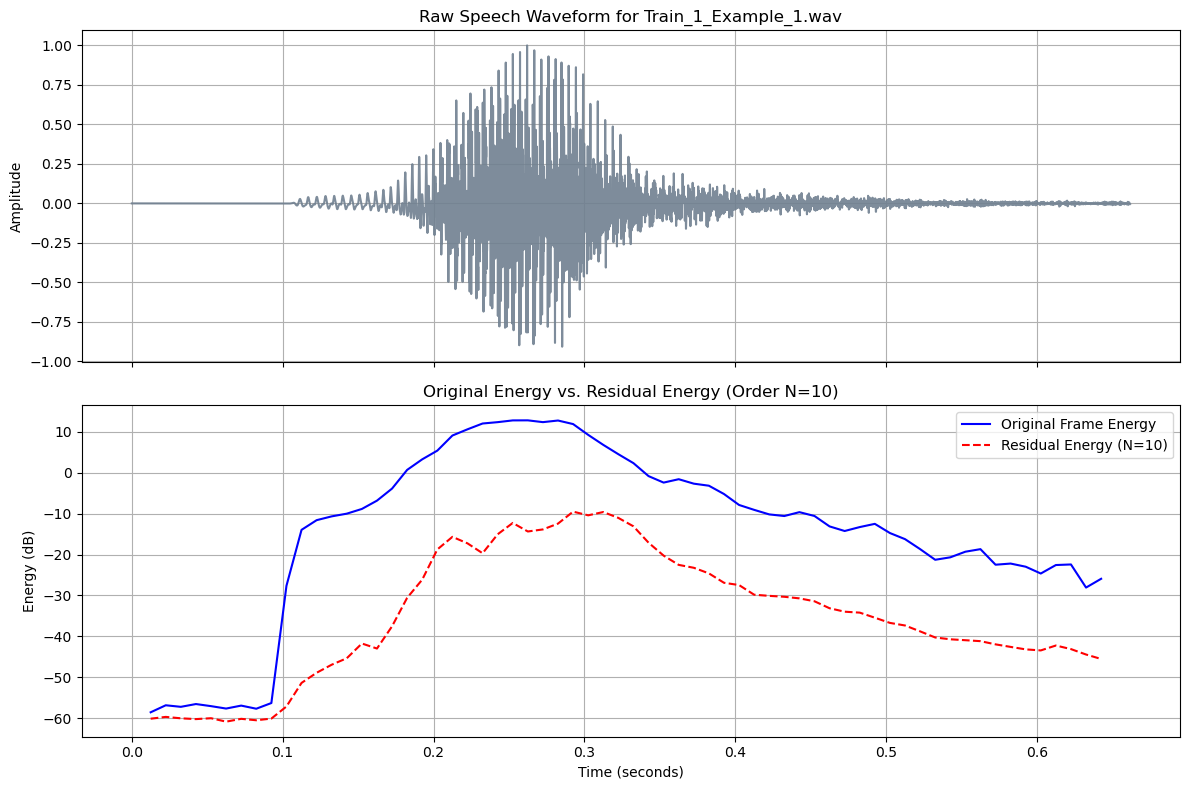

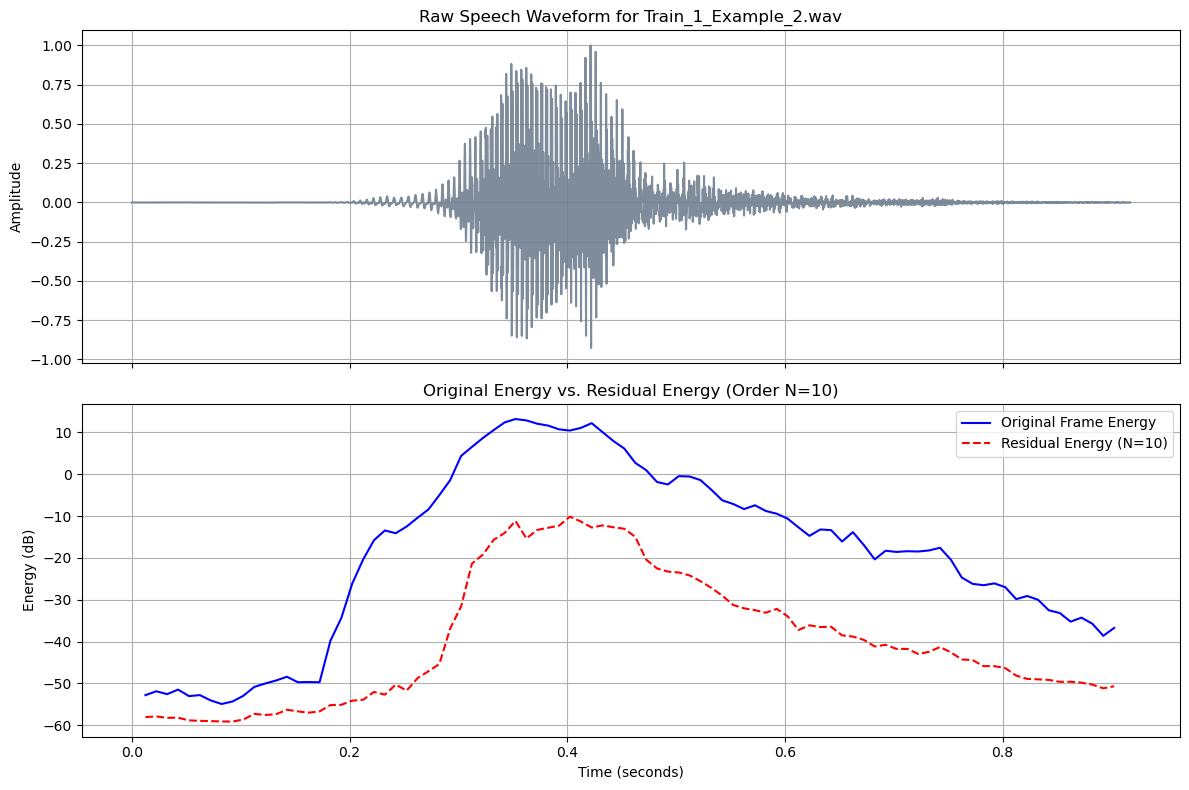

In [5]:
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    sr, y = wav.read(file_path)
    y = y.astype(np.float64) 
    y = y / (np.max(np.abs(y)) + 1e-10)
    file_name = file_name.replace('.wav', '')

    windowed_frames, frame_len, hop_len = frame_signal(y, sr, 25, 10)
    lpc_coeffs, residuals, residual_energy = compute_lpc_and_residual(windowed_frames, N_part_a)
    original_energy = np.sum(windowed_frames**2, axis=1)

    # For Visualization convenience
    original_energy_db = 10 * np.log10(original_energy + 1e-10)
    residual_energy_db = 10 * np.log10(residual_energy + 1e-10)

    t_wave = np.arange(len(y)) / sr
    t_frames = (np.arange(len(original_energy)) * hop_len + (frame_len / 2)) / sr

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    ax1.plot(t_wave, y, color='slategray', alpha=0.9)
    ax1.set_title(f'Raw Speech Waveform for {file_name + '.wav'}')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True)

    # Bottom Plot: Original Energy vs Residual Energy
    ax2.plot(t_frames, original_energy_db, label='Original Frame Energy', color='blue')
    ax2.plot(t_frames, residual_energy_db, label=f'Residual Energy (N={N_part_a})', color='red', linestyle='--')
    ax2.set_title(f'Original Energy vs. Residual Energy (Order N={N_part_a})')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Energy (dB)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plot_path = os.path.join('output', f'Plot_PartA_{file_name}.png')
    plt.savefig(plot_path)
    plt.show()
    plt.close()

### Q1.b)

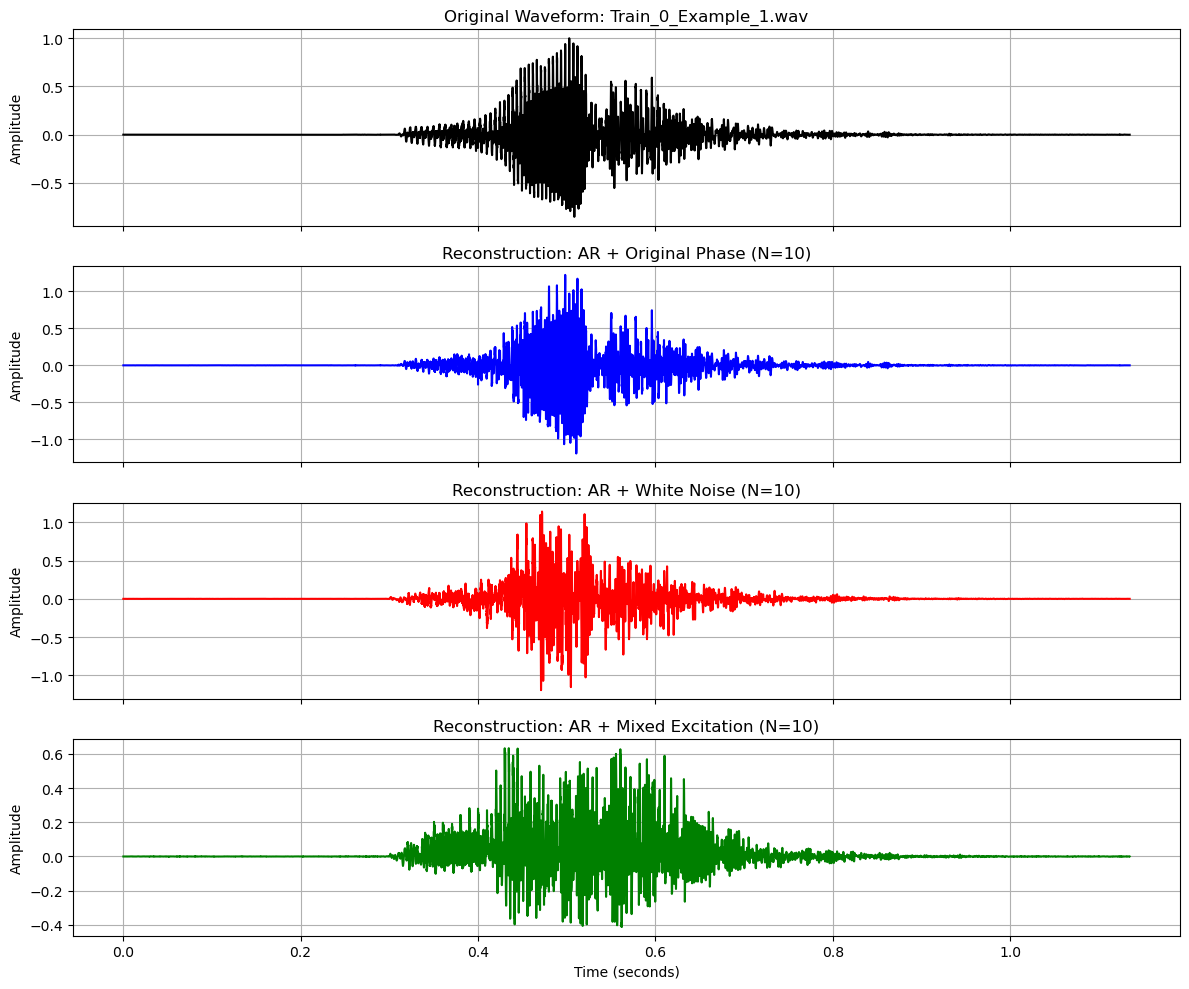

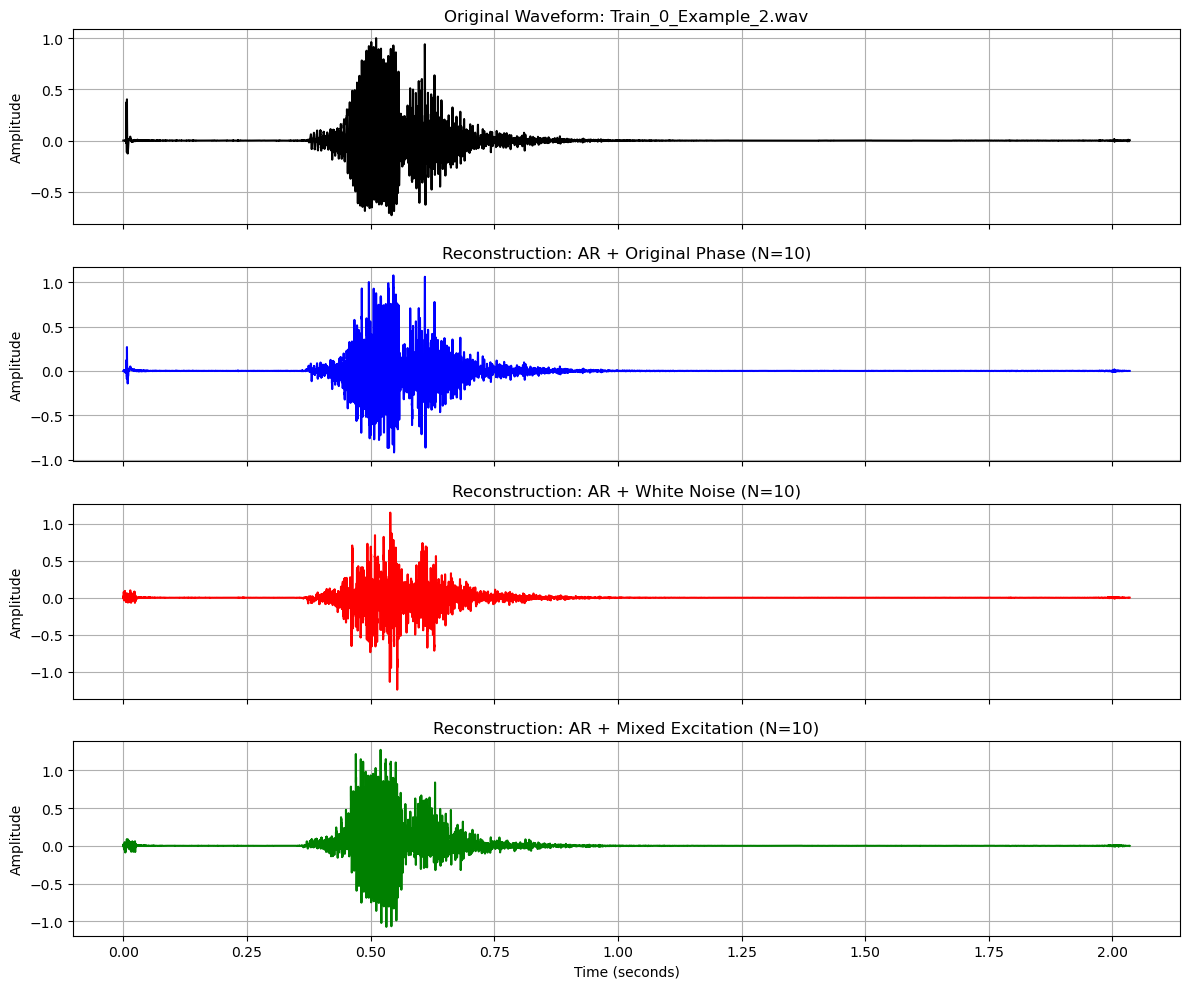

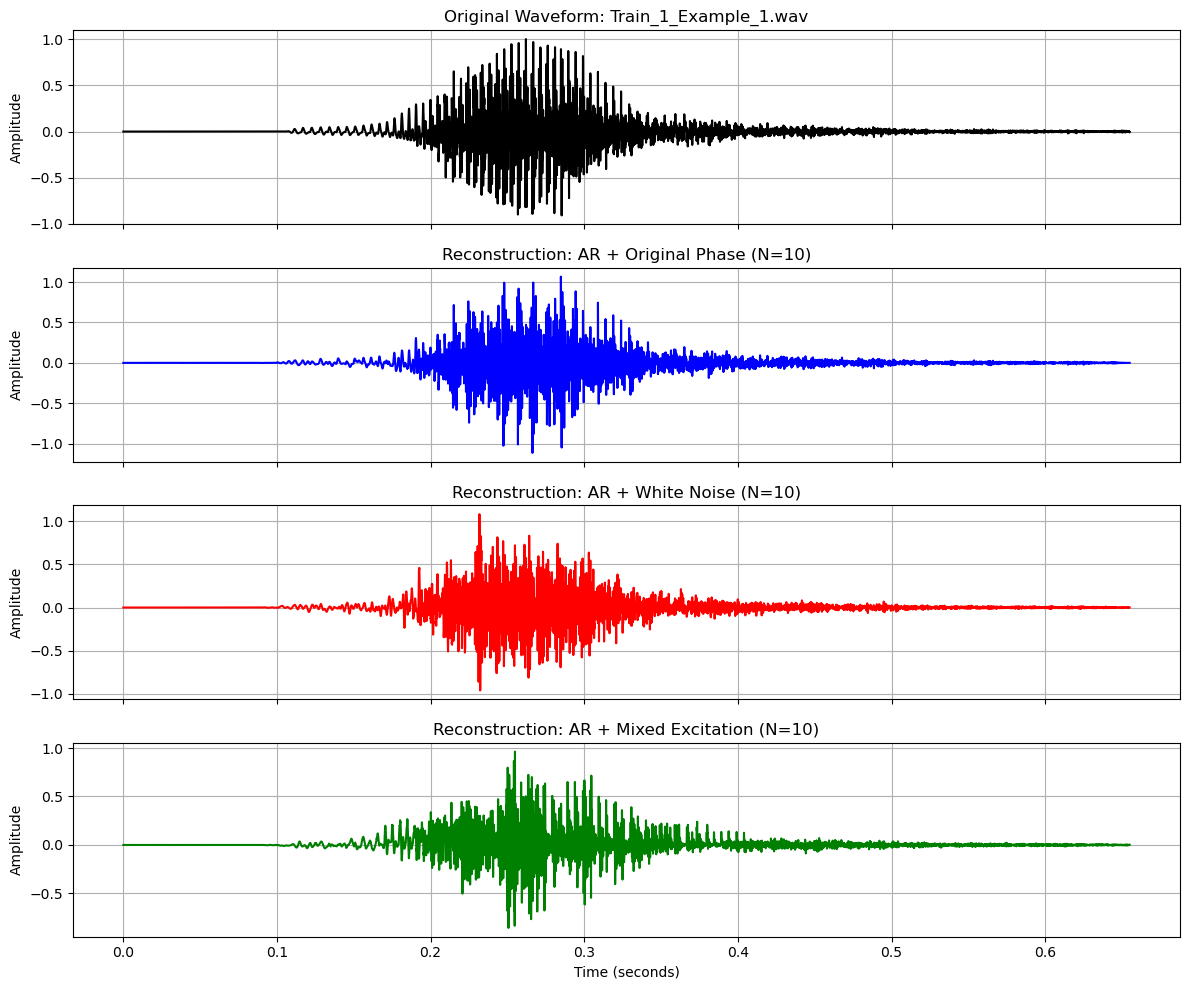

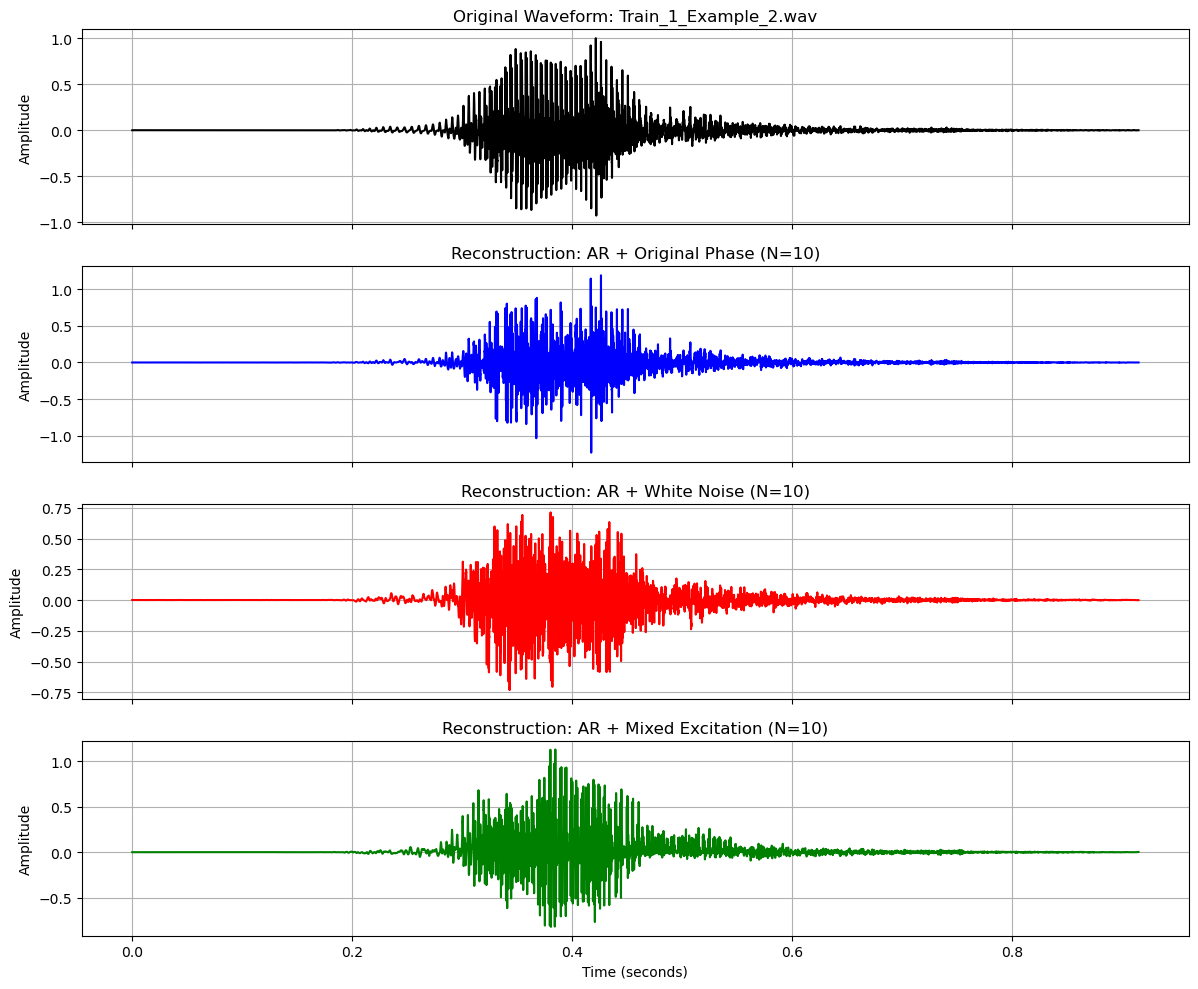

In [6]:
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    sr, y = wav.read(file_path)
    y = y.astype(np.float64) / (np.max(np.abs(y)) + 1e-10)
    windowed_frames, frame_len, hop_len = frame_signal(y, sr, 25, 10)
    is_voiced, pitch = estimate_voicing_and_pitch(windowed_frames, sr)

    lpc_N10, _, _ = compute_lpc_and_residual(windowed_frames, 10)
    frames_phase = reconstruct_ar_with_original_phase(windowed_frames, lpc_N10)
    frames_noise = synthesize_artificial(windowed_frames, lpc_N10, mode="white")
    frames_mix   = synthesize_artificial(windowed_frames, lpc_N10, mode="mixed", is_voiced=is_voiced, pitch=pitch)
    
    sig_phase = overlap_add(frames_phase, hop_len)
    sig_noise = overlap_add(frames_noise, hop_len)
    sig_mix   = overlap_add(frames_mix, hop_len)
    
    plot_waveforms_N10(file_name, y, sig_phase, sig_noise, sig_mix, sr, 'output')


In [ ]:
N_values_to_test = [2, 4, 6, 8, 10, 12, 14, 16, 20, 25, 30]

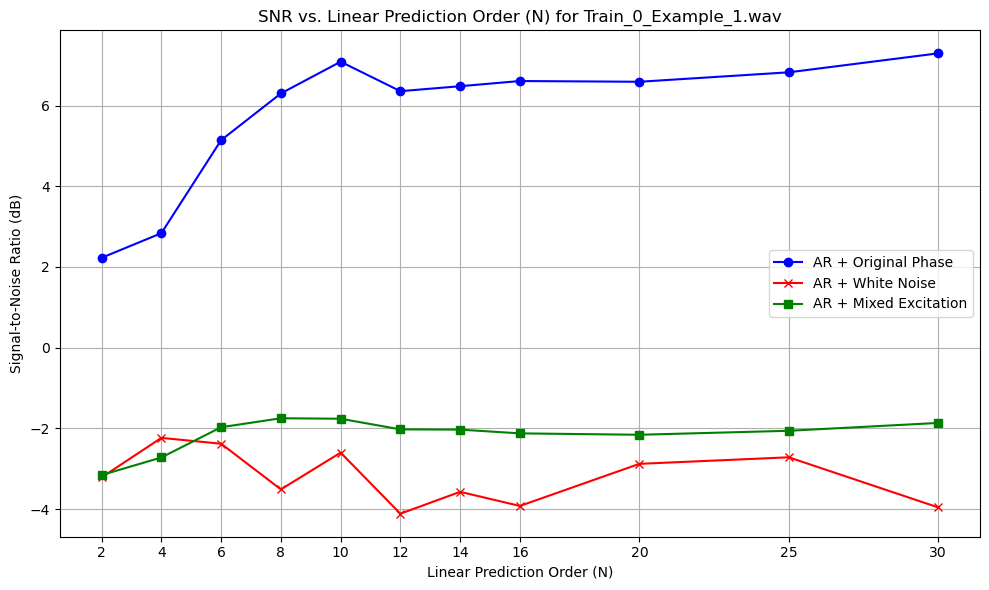

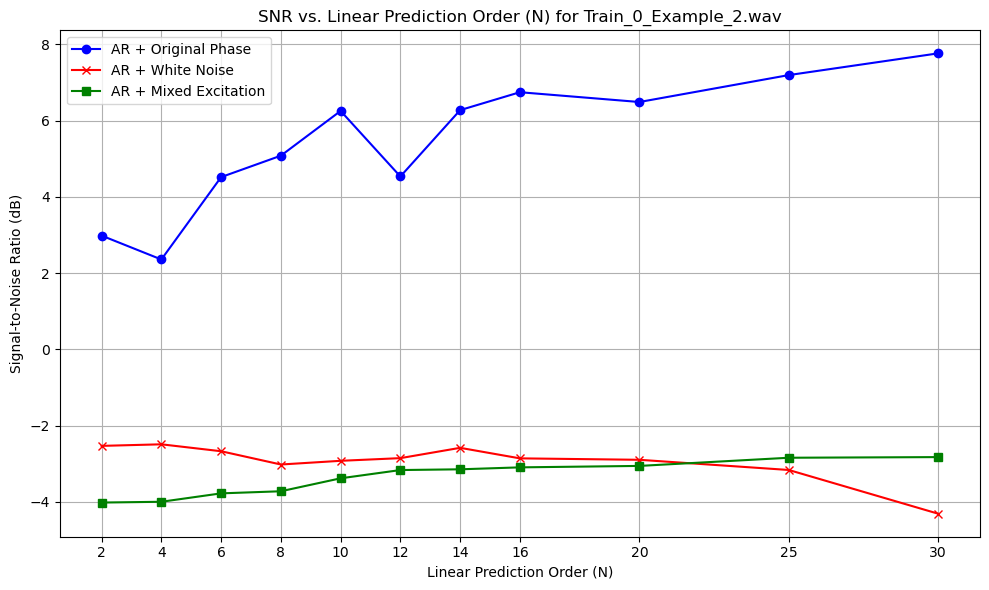

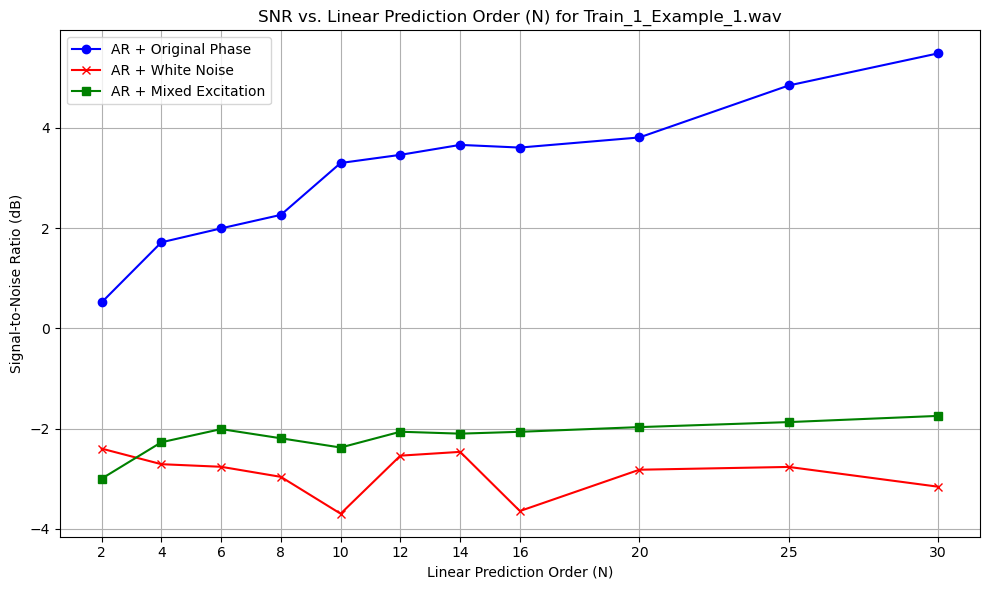

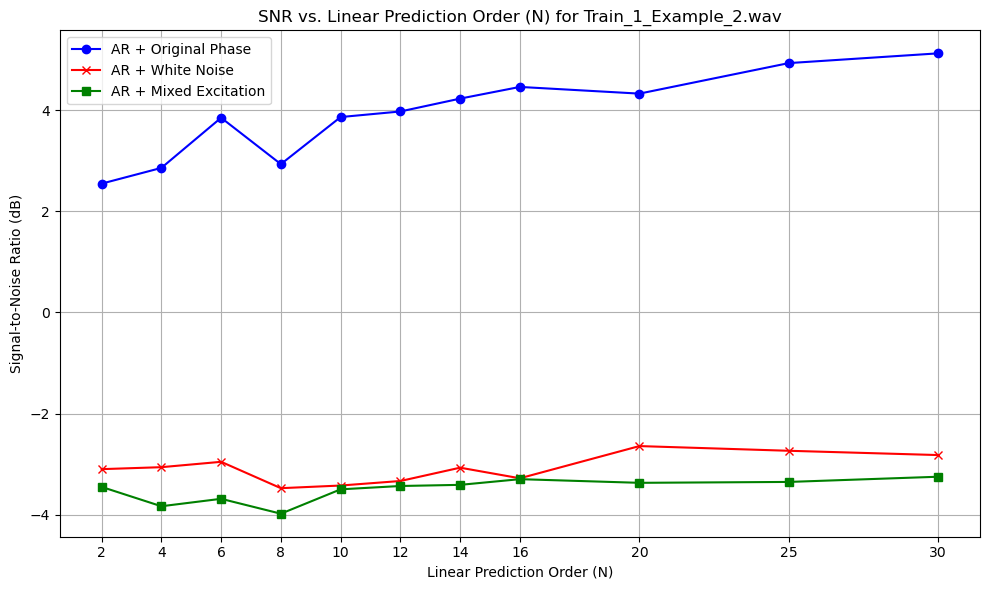

In [8]:
for file_name in files:
    file_path = os.path.join(data_dir, file_name)
    sr, y = wav.read(file_path)
    y = y.astype(np.float64) / (np.max(np.abs(y)) + 1e-10)
    windowed_frames, frame_len, hop_len = frame_signal(y, sr, 25, 10)
    is_voiced, pitch = estimate_voicing_and_pitch(windowed_frames, sr)

    snr_phase_list, snr_noise_list, snr_mix_list = [], [], []
        
    for N in N_values_to_test:
        lpc_N, _, _ = compute_lpc_and_residual(windowed_frames, N)
        
        sig_p = overlap_add(reconstruct_ar_with_original_phase(windowed_frames, lpc_N), hop_len)
        sig_n = overlap_add(synthesize_artificial(windowed_frames, lpc_N, mode="white"), hop_len)
        sig_m = overlap_add(synthesize_artificial(windowed_frames, lpc_N, mode="mixed", is_voiced=is_voiced, pitch=pitch), hop_len)
        
        snr_phase_list.append(calculate_snr(y, sig_p))
        snr_noise_list.append(calculate_snr(y, sig_n))
        snr_mix_list.append(calculate_snr(y, sig_m))
        
    plot_snr_analysis(file_name, N_values_to_test, snr_phase_list, snr_noise_list, snr_mix_list, 'output')

## Q2 Spectral Transform Linear Prediction

In [ ]:
def compute_stlp_and_plot(voiced_frame, unvoiced_frame, p_order, q_values, sr, file_name=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for idx in range(2):
        if idx == 0:
            frame = voiced_frame
            title = f"Voiced Frame ({file_name})"
        else:
            frame = unvoiced_frame
            title = f"Unvoiced Frame ({file_name})"
        N_fft = 1024
        X = np.fft.fft(frame, n=N_fft)
        S_xx = np.abs(X)**2
        S_xx = np.maximum(S_xx, 1e-10)
        freqs = np.fft.fftfreq(N_fft, 1/sr)
        half_idx = N_fft // 2
        axes[idx].plot(freqs[:half_idx], 10 * np.log10(S_xx[:half_idx]), color='black', label='Original True PSD $S_{xx}$', alpha=0.6, linewidth=1.5)
        colors = ['blue', 'red', 'green']
        
        for i, q in enumerate(q_values):
            S_xx_compressed = S_xx ** (1.0 / q)
            r_q = np.real(np.fft.ifft(S_xx_compressed))
            r_q_trunc = r_q[:p_order + 1]
            R_matrix = linalg.toeplitz(r_q_trunc[:-1])
            r_vector = r_q_trunc[1:]
            R_matrix.flat[::p_order+1] += 1e-6 
            a_k = linalg.solve(R_matrix, r_vector)
            a_coeffs = np.concatenate(([1.0], -a_k))
            gain_compressed = r_q_trunc[0] - np.dot(a_k, r_vector)
            gain_compressed = max(gain_compressed, 1e-10) 
            _, h = signal.freqz([1.0], a_coeffs, worN=N_fft, whole=True)
            S_hat_compressed = gain_compressed * (np.abs(h)**2)
            S_hat_expanded = S_hat_compressed ** q
            axes[idx].plot(freqs[:half_idx], 10 * np.log10(S_hat_expanded[:half_idx]), 
                    color=colors[i % len(colors)], 
                    label=f'STLP Approximation (q={q})', linewidth=2)

        axes[idx].set_title(f'STLP - {title}')
        axes[idx].set_xlabel('Frequency (Hz)')
        axes[idx].set_ylabel('Magnitude (dB)')
        axes[idx].set_xlim([0, sr/2])
        axes[idx].grid(True, linestyle='--', alpha=0.7)
        axes[idx].legend()
    plt.tight_layout()
    plt.savefig(os.path.join('output', f'STLP_voice_vs_unvoice_{file_name.replace(".wav", "")}.png'))
    plt.show()

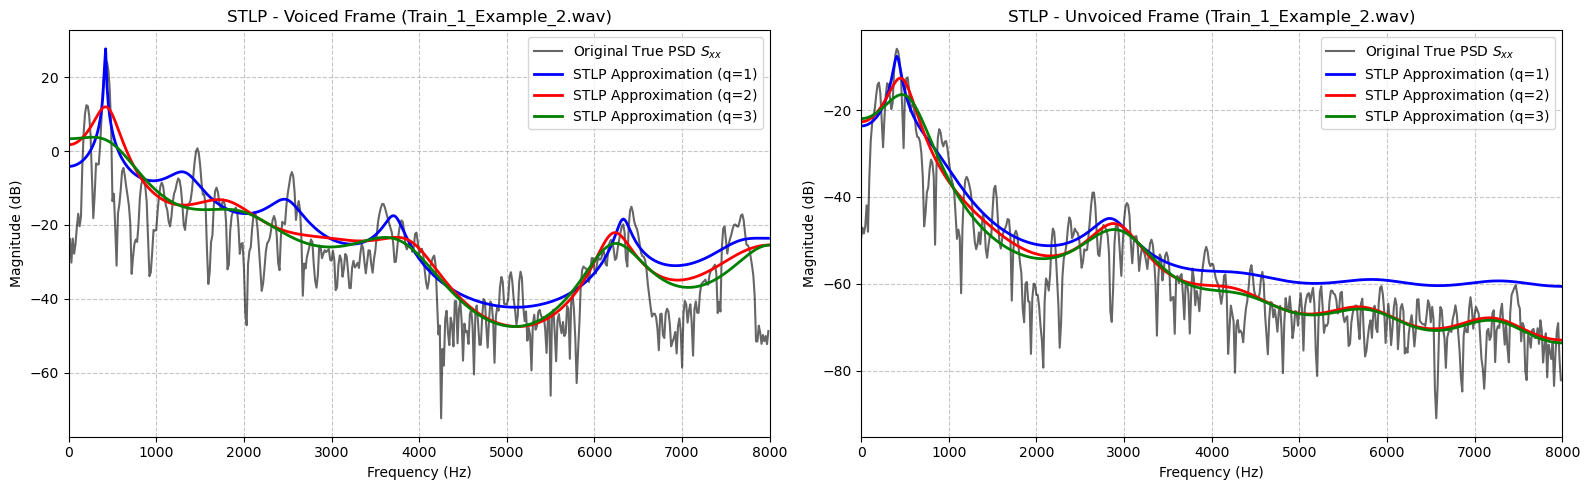

In [12]:
file_path = os.path.join(data_dir, files[0])

sr, y = wav.read(file_path)
if y.dtype == np.int16:
    y = y.astype(np.float32) / np.iinfo(np.int16).max
elif y.dtype == np.int32:
    y = y.astype(np.float32) / np.iinfo(np.int32).max
else:
    y = y.astype(np.float32)
if len(y.shape) > 1:
    y = np.mean(y, axis=1)

windowed_frames, frame_length, hop_length = frame_signal(y, sr, frame_len_ms=30, hop_len_ms=10)
is_voiced, pitch_periods = estimate_voicing_and_pitch(windowed_frames, sr)

voiced_indices = np.where(is_voiced == True)[0]
unvoiced_indices = np.where(is_voiced == False)[0]

if len(voiced_indices) > 0 and len(unvoiced_indices) > 0:
    voiced_frame = windowed_frames[voiced_indices[len(voiced_indices)//2]]
    unvoiced_frame = windowed_frames[unvoiced_indices[len(unvoiced_indices)//2]]
    
    p_order = 12 
    q_values = [1, 2, 3] 

    compute_stlp_and_plot(voiced_frame, unvoiced_frame, p_order, q_values, sr, file_name=file_name)